In [1]:
import os
import rasterio as rio
import numpy as np
import pandas as pd


from spectral import envi
import matplotlib.pyplot as plt
import matplotlib.path as pth
from pathlib import Path

from scipy.ndimage import binary_erosion
from pyproj import Transformer

import shapefile as shp

import Functions
import importlib

importlib.reload(Functions)

<module 'Functions' from '/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/Functions/Functions.py'>

In [2]:
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Data' / 'Ground_Campaign'

sentinel_path = Path('/media')/ 'frank' / 'USB' / 'SCUOLA' / 'App' / 'BACKSCATTER'

shape_path = input_path / 'Flevoland_data' / 'Data_25_fields' / 'Flevoland-fields-Shapefiles' / 'Feloveland-fields-Shapefiles'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [3]:
img_dates = Functions.read_dates_from_stack(sentinel_path)

shapes = list(shape_path.glob('*.shp'))
hdrs = list(sentinel_path.glob('*.hdr'))

Estraggo i poligoni dei campi

In [4]:
mypoly = { }

for file in shapes:

    file_stem = Path(file).stem
    poly = Functions.open_shp(file)

    if poly is not None:
        
        # Convert polygon coordinates to the target coordinate system (e.g., UTM)
        poly_utm_list = Functions.cambio_coord(poly)
        
        mypoly[file_stem] = {
            'coord': poly_utm_list, # Store the list of polygon parts/coordinates
            'path': [pth.Path(p) for p in poly_utm_list] # Create a list of Path objects for point-in-polygon tests
        }
    else:
        print(f"Skipping file {file} because it is invalid.")
        
    # print(f"The polygon has {len(mypoly[file_stem]['coord'])} parts.")

print(len(mypoly.keys()))

27


Reading SAR geographical coordinates

In [5]:
X_geo, Y_geo = Functions.axes_from_metadata(hdrs[0])

for key in mypoly:

    # 1. Find the total Bounding Box by merging all field parts
    # Stack all pieces to calculate global min/max
    all_coords = np.vstack(mypoly[key]['coord'])
    xmin, ymin = all_coords.min(axis=0)
    xmax, ymax = all_coords.max(axis=0)

    # 2. Find indices within the Sentinel image
    idx_x = np.where((X_geo >= xmin) & (X_geo <= xmax))[0]
    idx_y = np.where((Y_geo >= ymin) & (Y_geo <= ymax))[0]

    # 3. Create the point grid for cropping (Subset)
    r0, r1 = idx_y.min(), idx_y.max() + 1
    c0, c1 = idx_x.min(), idx_x.max() + 1

    X_sub = X_geo[c0:c1]
    Y_sub = Y_geo[r0:r1]
    
    # 4. Improved mask creation
    X_grid, Y_grid = np.meshgrid(X_sub, Y_sub)
    # Important: use stack to get clean (x, y) pairs
    points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))

    mymask_sub = np.zeros(X_grid.shape, dtype=bool)
    # Iterate over each Path object in the previously saved list
    for pth_obj in mypoly[key]['path']:
        # Create the mask for the single part and merge it using logical OR (|)
        # Use standard 'C' order and then .reshape()
        current_part_mask = pth_obj.contains_points(points).reshape(X_grid.shape)
        mymask_sub |= current_part_mask

    # Apply binary erosion to avoid edge effects
    mask_eroted = binary_erosion(mymask_sub, structure=np.ones((3,3))).astype(mymask_sub.dtype)
    mypoly[key]['mask_sub'] = mask_eroted # mymask_sub
    mypoly[key]['r_range'] = (r0, r1)
    mypoly[key]['c_range'] = (c0, c1)

# Final Debug
field = 'AKW-G1_C'
print(f"Starting column index for {field}: {mypoly[field]['c_range'][0]}")
print(f"Eroded mask shape: {mypoly[field]['mask_sub'].shape}")

Starting column index for AKW-G1_C: 5240
Eroded mask shape: (33, 35)


ReadingSAR images and saving the average and the std in a dictionary:
poly_stats[name_polygon][data+VV/VH][avg/std]

In [6]:
poly_stats = {k: {} for k in mypoly}

for file in hdrs:

    file_path = Path(file)
    file_stem = file_path.stem
    date = file_stem[:8] # Assuming YYYYMMDD format
    
    # 1. Open the file (without loading it into RAM!)
    img_obj = Functions.read_img2(file, '')

    # Determine polarization from the filename
    pol = 'VH' if 'VH' in file_stem else 'VV'
    name = f'{date}_{pol}'

    print(f'Processing {pol} for date {date}...')

    for key in mypoly:
        r1, r2 = mypoly[key]['r_range']
        c1, c2 = mypoly[key]['c_range']
    
        # 2. READ ONLY THE SUBREGION FROM DISK
        # read_subregion( (r_start, r_end), (c_start, c_end) )
        radar_sub = img_obj.read_subregion((r1, r2), (c1, c2))
        
        # Squeeze dimensions (from (H, W, 1) to (H, W))
        radar_sub = np.squeeze(radar_sub)
    
        # 3. Apply the eroded mask
        pixel_campo = radar_sub[mypoly[key]['mask_sub']]

        if len(pixel_campo) > 0:
            if name not in poly_stats[key]:
                poly_stats[key][name] = {}
            
            # Linear scale calculation
            m_lin = np.mean(pixel_campo)
            s_lin = np.std(pixel_campo)
            
            # Saving results (you can also add dB conversion here)
            poly_stats[key][name]['mean'] = m_lin
            poly_stats[key][name]['std'] = s_lin

        else:
            print(f"Warning: no valid pixels for {key} in {file_stem}")

# Manual memory cleanup at the end of each file (optional)
del img_obj

Processing VH for date 20170104...
Processing VV for date 20170104...
Processing VH for date 20170110...
Processing VV for date 20170110...
Processing VH for date 20170116...
Processing VV for date 20170116...
Processing VH for date 20170122...
Processing VV for date 20170122...
Processing VH for date 20170128...
Processing VV for date 20170128...
Processing VH for date 20170203...
Processing VV for date 20170203...
Processing VH for date 20170209...
Processing VV for date 20170209...
Processing VH for date 20170215...
Processing VV for date 20170215...
Processing VH for date 20170221...
Processing VV for date 20170221...
Processing VH for date 20170227...
Processing VV for date 20170227...
Processing VH for date 20170305...
Processing VV for date 20170305...
Processing VH for date 20170311...
Processing VV for date 20170311...
Processing VH for date 20170317...
Processing VV for date 20170317...
Processing VH for date 20170323...
Processing VV for date 20170323...
Processing VH for da

In [7]:
print(poly_stats['DB_A_C']['20170104_VV'])

{'mean': np.float32(-7.172247), 'std': np.float32(1.05917)}


Dataframe with statistics

In [8]:
Nme_types = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Name_Type.csv',header=0)

In [9]:
rows = []
for roi, dates_dict in poly_stats.items():
    for date_band, stats in dates_dict.items():
        row = {'ROI': roi, 'Date_Band': date_band}
        row.update(stats) # Aggiunge 'mean', 'std', ecc. come colonne
        rows.append(row)

df_stats = pd.DataFrame(rows)

df_stats[['Date', 'Band']] = df_stats['Date_Band'].str.split('_', expand=True)
df_stats['Date'] = pd.to_datetime(df_stats['Date'])
df_stats = df_stats.merge(Nme_types, on='ROI', how='left')
display(df_stats)


,ROI,Date_Band,mean,std,Date,Band,Type
0,DB_A_C,20170104_VH,-14.988747,1.152336,2017-01-04,VH,Aardappelen
1,DB_A_C,20170104_VV,-7.172247,1.059170,2017-01-04,VV,Aardappelen
2,DB_A_C,20170110_VH,-13.919929,0.968011,2017-01-10,VH,Aardappelen
3,DB_A_C,20170110_VV,-5.792219,0.991691,2017-01-10,VV,Aardappelen
4,DB_A_C,20170116_VH,-20.690327,1.066293,2017-01-16,VH,Aardappelen
...,...,...,...,...,...,...,...
3181,DB_SB1_C,20171218_VV,-5.278055,1.091359,2017-12-18,VV,Bieten
3182,DB_SB1_C,20171224_VH,-13.429222,0.918860,2017-12-24,VH,Bieten
3183,DB_SB1_C,20171224_VV,-5.429169,1.148561,2017-12-24,VV,Bieten
3184,DB_SB1_C,20171230_VH,-12.458362,0.862726,2017-12-30,VH,Bieten


Visualizing the mask of a polygon and the mean value

-11.187754


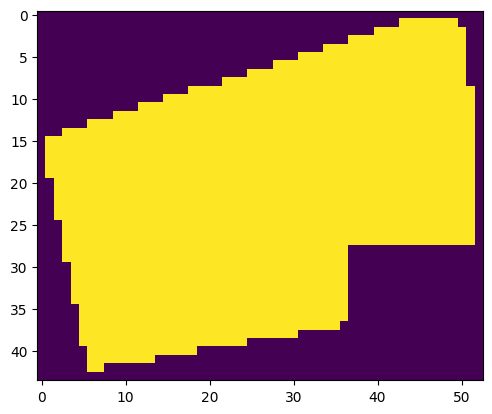

In [10]:
print(poly_stats['KL_MA_1_C']['20170305_VV']['mean'])
plt.imshow(mypoly['DB_A_C']['mask_sub'])

(6346, 7025)



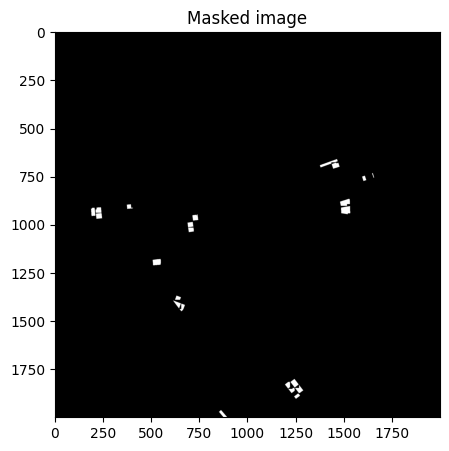

In [11]:
full_mask = np.zeros((len(Y_geo), len(X_geo)), dtype=bool)
print(full_mask.shape)

_ , IMG = Functions.read_img(hdrs[0],'')

# 2. Inserisci la maschera piccola nella posizione corretta usando gli indici
# idx_y e idx_x definiscono le "coordinate matriciali" in cui incollare il pezzo
print()
for i in mypoly:

    full_mask[mypoly[i]['r_range'][0]:mypoly[i]['r_range'][1], 
              mypoly[i]['c_range'][0]:mypoly[i]['c_range'][1]] = mypoly[i]['mask_sub']

plt.figure(figsize=(5,5))
plt.imshow(full_mask[1000:3000,4000:6000], cmap='gray')
plt.title("Masked image")
plt.show()

In [12]:
df_stats.to_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/TimeSeries_sigma.csv', index=False)

GRAFICI DELLE STATISTICHE

In [13]:
from matplotlib.backends.backend_pdf import PdfPages
# 1. Trasformazione del dizionario in DataFrame (Formato Lungo)
# Definisci il nome del file di uscita

output_folder = app_path / 'Documents'
output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Time_Series_ROI_BACKSCATTER.pdf'

with PdfPages(pdf_filename) as pdf:
    unique_rois = df_stats['ROI'].unique()

    for roi in unique_rois:
        # Crea la figura
        plt.figure(figsize=(12, 6))
        roi_data = df_stats[df_stats['ROI'] == roi]
        
        for band in roi_data['Band'].unique():
            band_data = roi_data[roi_data['Band'] == band]
            
            # Plot della linea media
            line, = plt.plot(band_data['Date'], band_data['mean'], 
                             marker='o', linestyle='-', linewidth=2, label=f'Mean {band}')
            
            # Area della deviazione standard (Mean ± Std) con rf'' per LaTeX
            plt.fill_between(
                band_data['Date'], 
                band_data['mean'] - band_data['std'], 
                band_data['mean'] + band_data['std'], 
                color=line.get_color(), 
                alpha=0.15, 
                label=rf'Dispersion $\pm 1\sigma$ ({band})'
            )

        # Formattazione estetica
        plt.title(f"Time Series ROI: {roi}", fontsize=14, fontweight='bold')
        plt.xlabel("Data", fontsize=12)
        plt.ylabel("Value (Reflectance / Backscatter)", fontsize=12)
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Legenda fuori dal grafico
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        pdf.savefig()
        
        plt.close()

print(f"Done! All graphs had been saved in : {pdf_filename}")


Done! All graphs had been saved in : /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/Time_Series_ROI_BACKSCATTER.pdf
